In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [3]:
# PLot aesthetic
sns.set_theme(style="whitegrid")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"

In [4]:
#Starting with EDA

In [9]:
df = pd.read_csv('employees_dataset (1).csv')

In [13]:
print("---Initial Data Summary---")
print(f"Dataset Shape: {df.shape}")
print(df.info())
print("\n Descriptive Stats(Numerical):")
print(df.describe().T)

---Initial Data Summary---
Dataset Shape: (17417, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17417 entries, 0 to 17416
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   employee_id            17417 non-null  int64  
 1   department             17417 non-null  object 
 2   region                 17417 non-null  object 
 3   education              16646 non-null  object 
 4   gender                 17417 non-null  object 
 5   recruitment_channel    17417 non-null  object 
 6   no_of_trainings        17417 non-null  int64  
 7   age                    17417 non-null  int64  
 8   previous_year_rating   16054 non-null  float64
 9   length_of_service      17417 non-null  int64  
 10  KPIs_met_more_than_80  17417 non-null  int64  
 11  awards_won             17417 non-null  int64  
 12  avg_training_score     17417 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 1.7

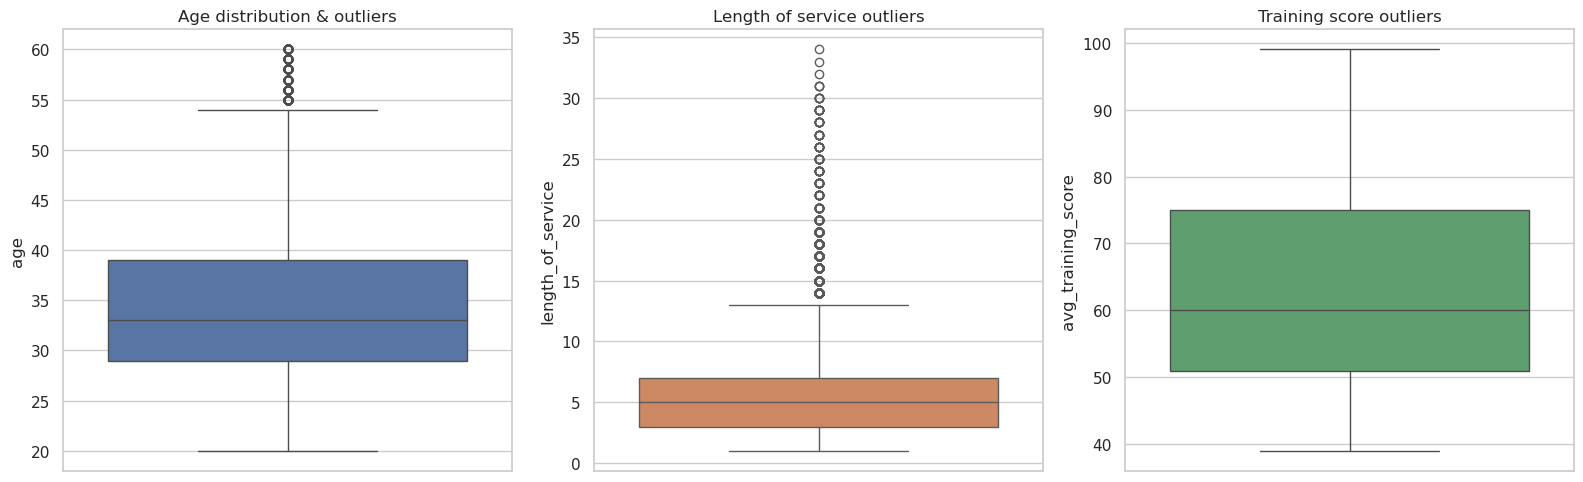

In [14]:
#Detecting outliers using boxplot
fig, axes= plt.subplots(1, 3, figsize=(16, 5))
sns.boxplot(y='age', data=df, ax=axes[0], color='#4C72B0')
axes[0].set_title('Age distribution & outliers')

sns.boxplot(y='length_of_service', data=df, ax=axes[1], color='#DD8452')
axes[1].set_title('Length of service outliers')

sns.boxplot(y='avg_training_score', data=df, ax=axes[2], color='#55A868')
axes[2].set_title('Training score outliers')
plt.tight_layout()
plt.savefig('eda_outliers.png')
plt.show()

In [ ]:
#Lets start with data preprocessing

In [15]:
clean_df = df.copy()

In [16]:
#Handling missing values
clean_df['education'] = clean_df['education'].fillna(clean_df['education'].mode()[0])
clean_df['previous_year_rating'] = clean_df['previous_year_rating'].fillna(clean_df['previous_year_rating'].median())

In [17]:
#Feature engineering
clean_df['age_group'] = pd.cut(clean_df['age'], bins=[0, 29, 45, 100], labels=['Under 30','30-45', '45+'])
clean_df['tenure_band'] = pd.cut(clean_df['length_of_service'], bins=[-1, 2, 7, 100], labels=['New hire(0-2 yrs)', 'Mid tenure(3-7 yrs)', 'Senior(8+ yrs)'])

In [18]:
#Defining high performance/ retention target
clean_df['high_performer'] = np.where((clean_df['KPIs_met_more_than_80']==1) & (clean_df['previous_year_rating']>= 4.0), 1,0)
print("\nMissing values remaining:")
print(clean_df.isnull().sum())


Missing values remaining:
employee_id              0
department               0
region                   0
education                0
gender                   0
recruitment_channel      0
no_of_trainings          0
age                      0
previous_year_rating     0
length_of_service        0
KPIs_met_more_than_80    0
awards_won               0
avg_training_score       0
age_group                0
tenure_band              0
high_performer           0
dtype: int64


In [ ]:
#Key metrics & trend analysis

In [19]:
#Grouped agg by department
dept_metrics = clean_df.groupby('department').agg(
    total_employees = ('employee_id', 'count'),
    avg_score = ('avg_training_score','mean'),
    kpi_met_rate = ('KPIs_met_more_than_80','mean'),
    high_performer_rate = ('high_performer','mean')
).reset_index()

print("\n--- Key metrics by department---")
print(dept_metrics)


--- Key metrics by department---
          department  total_employees  avg_score  kpi_met_rate  \
0          Analytics             1697  84.565115      0.400118   
1            Finance              802  60.326683      0.397756   
2                 HR              833  50.387755      0.360144   
3              Legal              332  59.533133      0.355422   
4         Operations             3524  60.351589      0.440692   
5        Procurement             2240  70.180357      0.373214   
6                R&D              332  84.451807      0.448795   
7  Sales & Marketing             5458  50.056614      0.277208   
8         Technology             2199  79.847658      0.356071   

   high_performer_rate  
0             0.230407  
1             0.251870  
2             0.219688  
3             0.198795  
4             0.284620  
5             0.217857  
6             0.319277  
7             0.149505  
8             0.202819  


C:\Users\ā\AppData\Local\Temp\ipykernel_7276\638873891.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = dept_metrics.sort_values(by= 'kpi_met_rate', ascending=False), x='department', y='kpi_met_rate', palette='Blues_r')


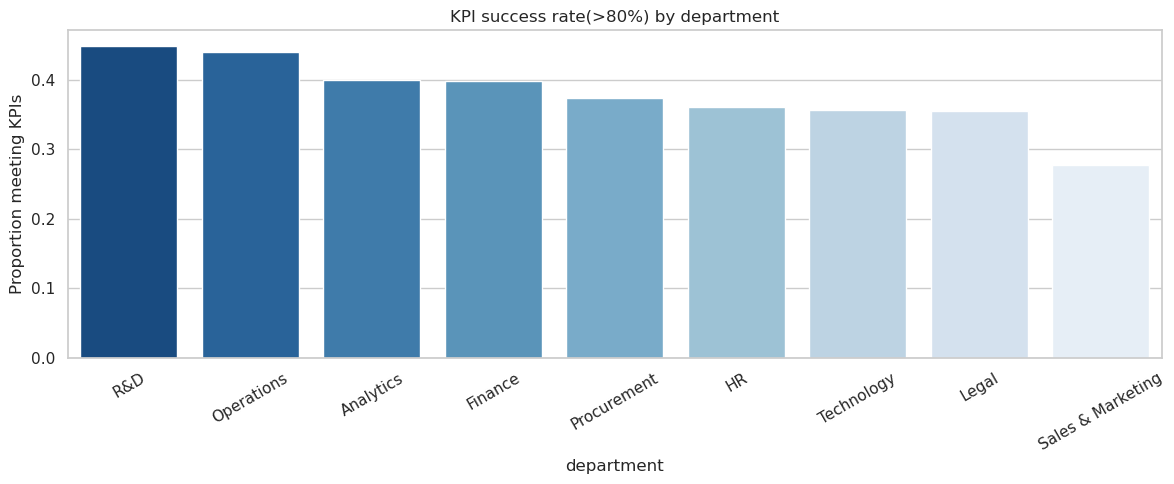

In [21]:
#Visualisation of KPI success rate across department
plt.figure(figsize=(12, 5))
sns.barplot(data = dept_metrics.sort_values(by= 'kpi_met_rate', ascending=False), x='department', y='kpi_met_rate', palette='Blues_r')
plt.title('KPI success rate(>80%) by department')
plt.xticks(rotation=30)
plt.ylabel('Proportion meeting KPIs')
plt.tight_layout()
plt.savefig('dept_kpi_rate.png')
plt.show()

C:\Users\ā\AppData\Local\Temp\ipykernel_7276\625126704.py:4: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  clean_df.pivot_table(index='education', columns='age_group', values='high_performer', aggfunc='mean'),


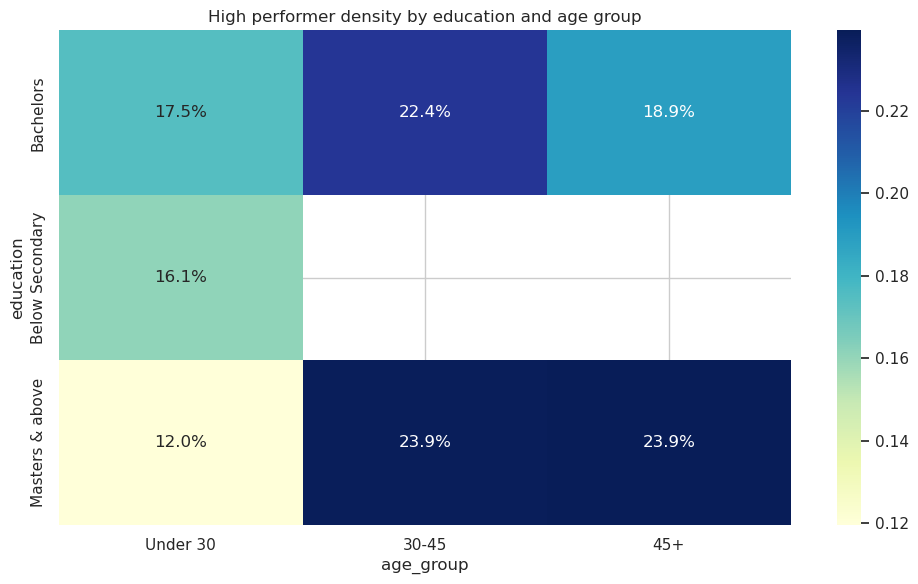

In [23]:
#Visualisation of high performer by education & age group
plt.figure(figsize=(10, 6))
sns.heatmap(
    clean_df.pivot_table(index='education', columns='age_group', values='high_performer', aggfunc='mean'),
    annot=True, fmt=".1%", cmap="YlGnBu"
)
plt.title('High performer density by education and age group')
plt.tight_layout()
plt.savefig('retention_demographics.png')
plt.show()

In [24]:
#Predictive insights

In [25]:
#Features and target
features = ['department', 'education', 'gender', 'recruitment_channel', 'no_of_trainings', 'age', 'previous_year_rating', 
            'length_of_service', 'avg_training_score']
x = clean_df[features]
y = clean_df['high_performer']

categorical_cols = ['department', 'education', 'gender', 'recruitment_channel']
numerical_cols = ['no_of_trainings', 'age', 'previous_year_rating', 'length_of_service', 'avg_training_score']


In [28]:
# Pipeline preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
model.fit(X_train_proc, y_train)

# Model Evaluation
y_pred = model.predict(X_test_proc)
y_proba = model.predict_proba(X_test_proc)[:, 1]

print("\n--- Model Evaluation ---")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


--- Model Evaluation ---
ROC-AUC Score: 0.9206

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.92      0.90      2744
           1       0.66      0.58      0.62       740

    accuracy                           0.85      3484
   macro avg       0.77      0.75      0.76      3484
weighted avg       0.84      0.85      0.84      3484



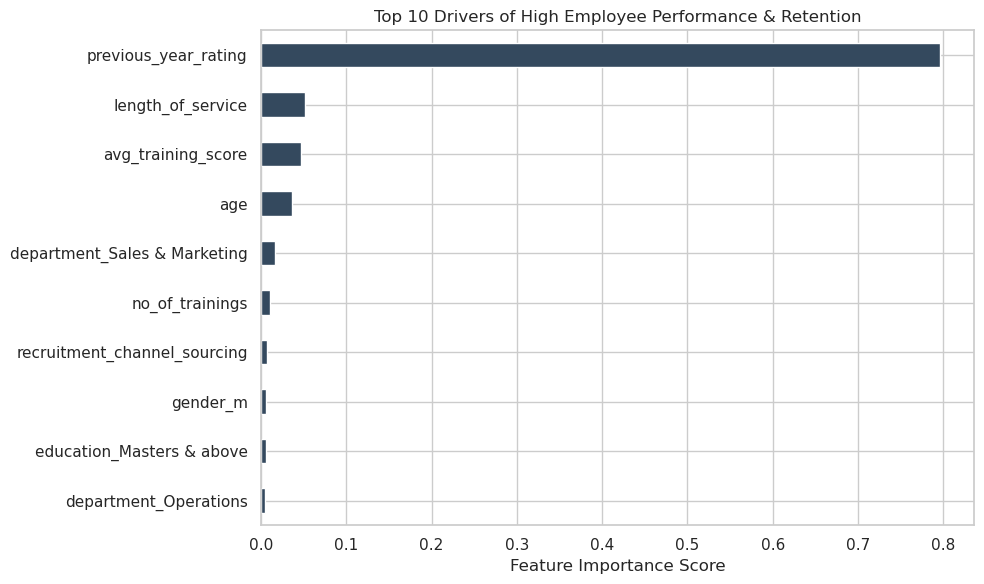

In [29]:
# Feature Importance Extraction
encoded_cat_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols)
all_feature_names = numerical_cols + list(encoded_cat_names)
importances = pd.Series(model.feature_importances_, index=all_feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importances.head(10).plot(kind='barh', color='#34495e').invert_yaxis()
plt.title('Top 10 Drivers of High Employee Performance & Retention')
plt.xlabel('Feature Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()